## Package Importation

In [1]:

import glob
import zipfile
import os
import pandas as pd
import shutil
import csv
import math
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import holidays
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Data Ingestion

In [2]:
### Rebuilding function - we chunk the data initially so we can push the data in GIT. 
### To rebuild the data, we create a rebuild function

def rebuild_function(directory_path, file_pattern='*.csv'):
    """
    Rebuild chunked data from a specified directory into a single DataFrame.

    Args:
    directory_path (str): Full path to the directory containing the chunked data files.
    file_pattern (str): Pattern to match the chunked files (default: '*.csv').

    Returns:
    pandas.DataFrame: Concatenated data from all chunks.
    """
    # Use glob to find all files matching the pattern in the specified directory
    all_files = glob.glob(os.path.join(directory_path, file_pattern))
    
    if not all_files:
        print(f"No files found in {directory_path} matching pattern {file_pattern}")
        return None
    
    # Sort the files to ensure they're processed in the correct order
    all_files.sort()
    
    # Read and concatenate all files
    td_list = []
    for filename in all_files:
        try:
            td = pd.read_csv(filename)
            td_list.append(td)  # Append to the correct list
        except Exception as e:
            print(f"Error reading file {filename}: {str(e)}")
    
    if not td_list:  # Fix the list name here
        print(f"No data could be read from files in {directory_path}")
        return None
    
    # Concatenate all dataframes
    combined_df = pd.concat(td_list, ignore_index=True)
    
    return combined_df

In [3]:
# Use the function
# data_nsw - forecasted demand
# temp - is the temperature
# td - is the total demand
nsw = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_fcastd_nsw\forecastdemand_nsw_chunks"
data_nsw = rebuild_function(nsw, "forecastdemand_nsw_part*.csv")
# Load the NSW Temperature and perform basic exploratory analysis
file_path = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_nsw\temperature_nsw.csv"
temp = pd.read_csv(file_path)
file_path = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_nsw\totaldemand_nsw.csv"
td = pd.read_csv(file_path)

vic = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_au\a\forecastdemand_vic_chunks"
data_vic = rebuild_function(vic, "forecastdemand_vic_part*.csv")

sa = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_au\b\forecastdemand_sa_chunks"
data_sa = rebuild_function(sa, "forecastdemand_sa_part*.csv")

qld = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_au\c\forecastdemand_qld_chunks"
data_qld = rebuild_function(qld, "forecastdemand_qld_part*.csv")

nsw = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_fcastd_nsw\forecastdemand_nsw_chunks"
data_nsw = rebuild_function(nsw, "forecastdemand_nsw_part*.csv")


## Descriptive Analytics

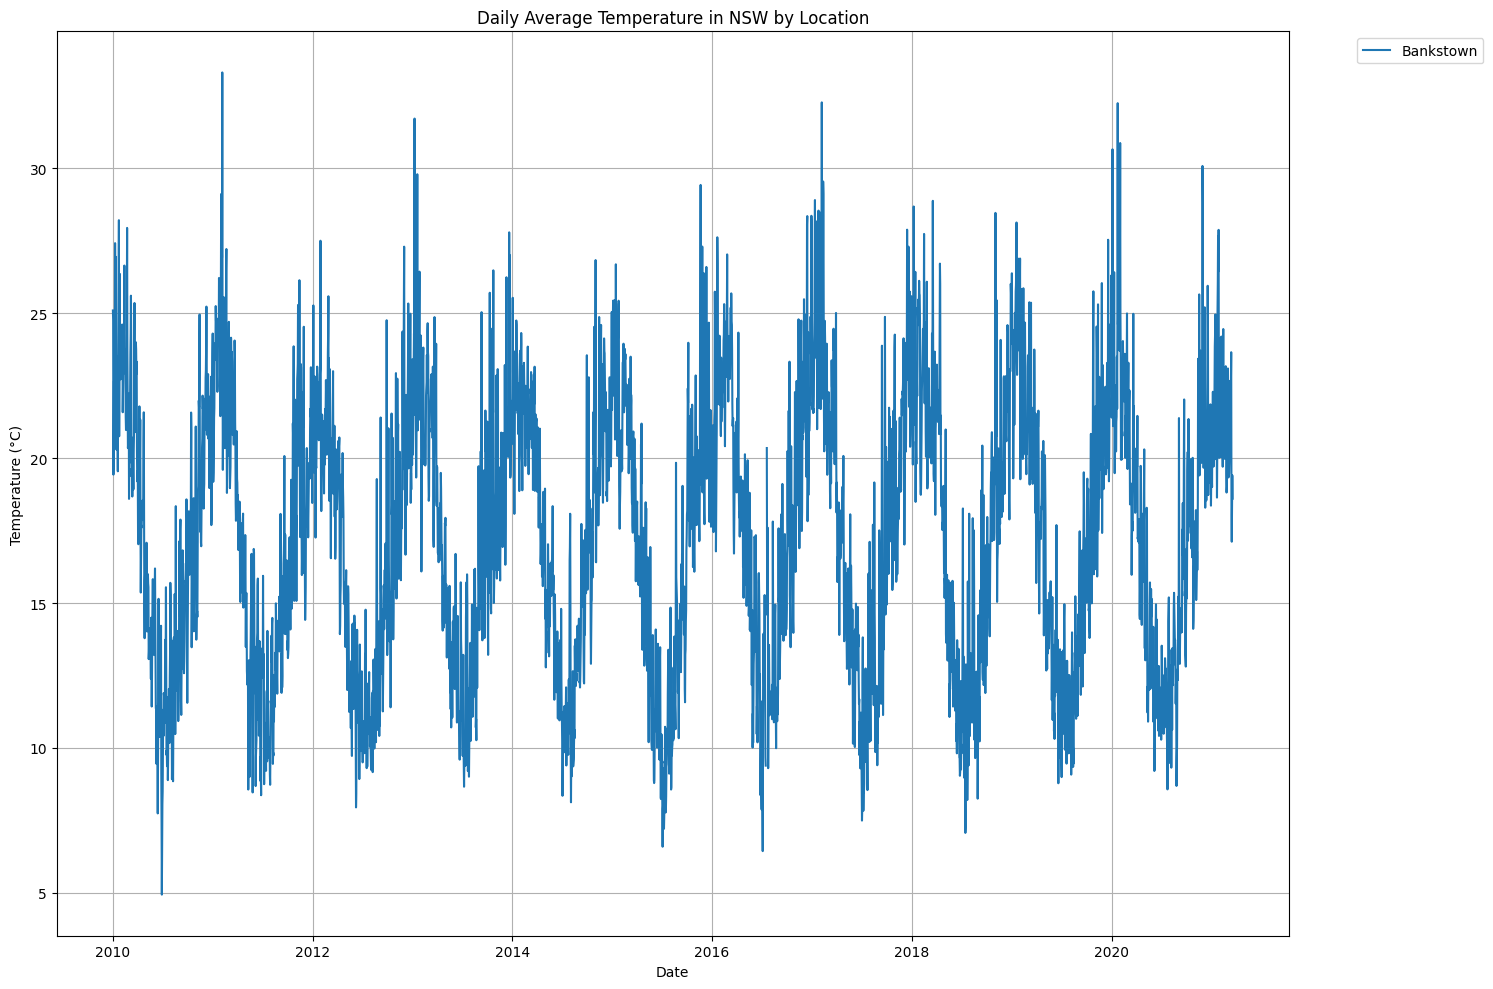

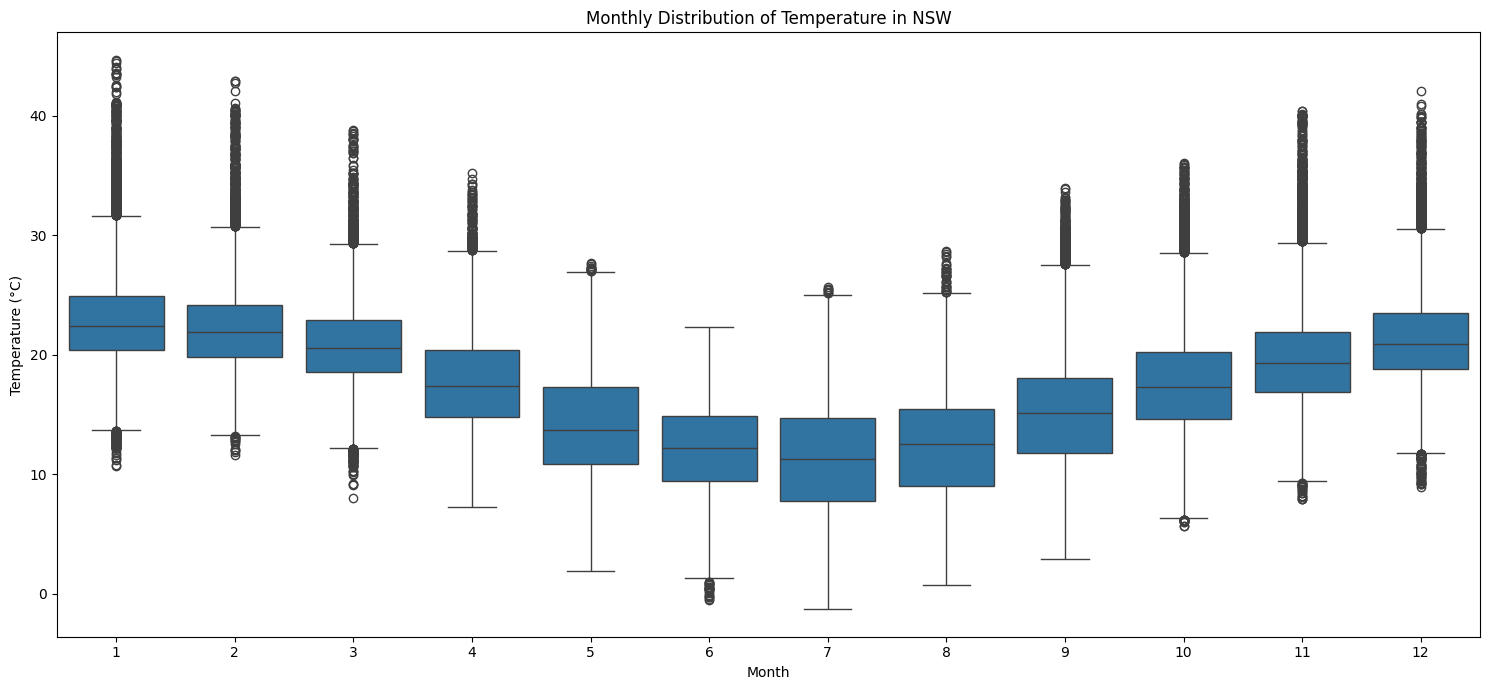

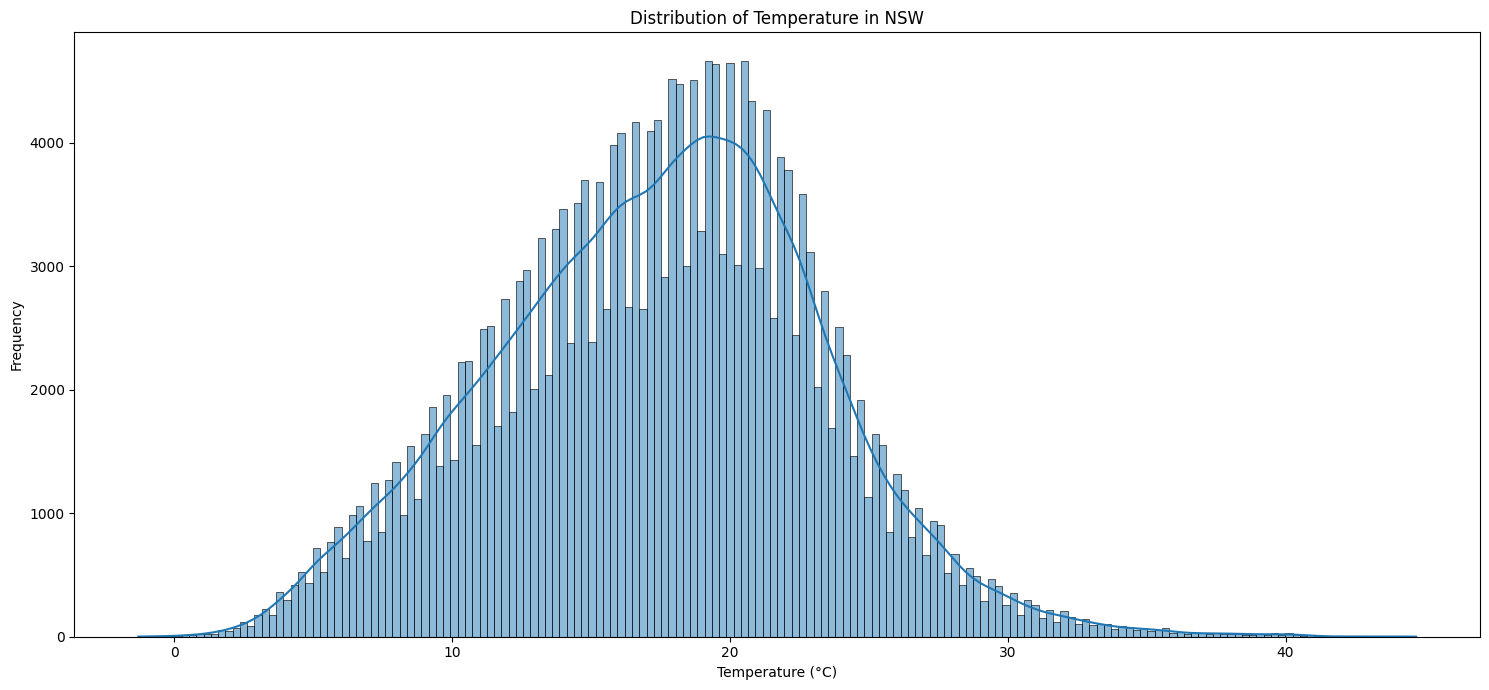

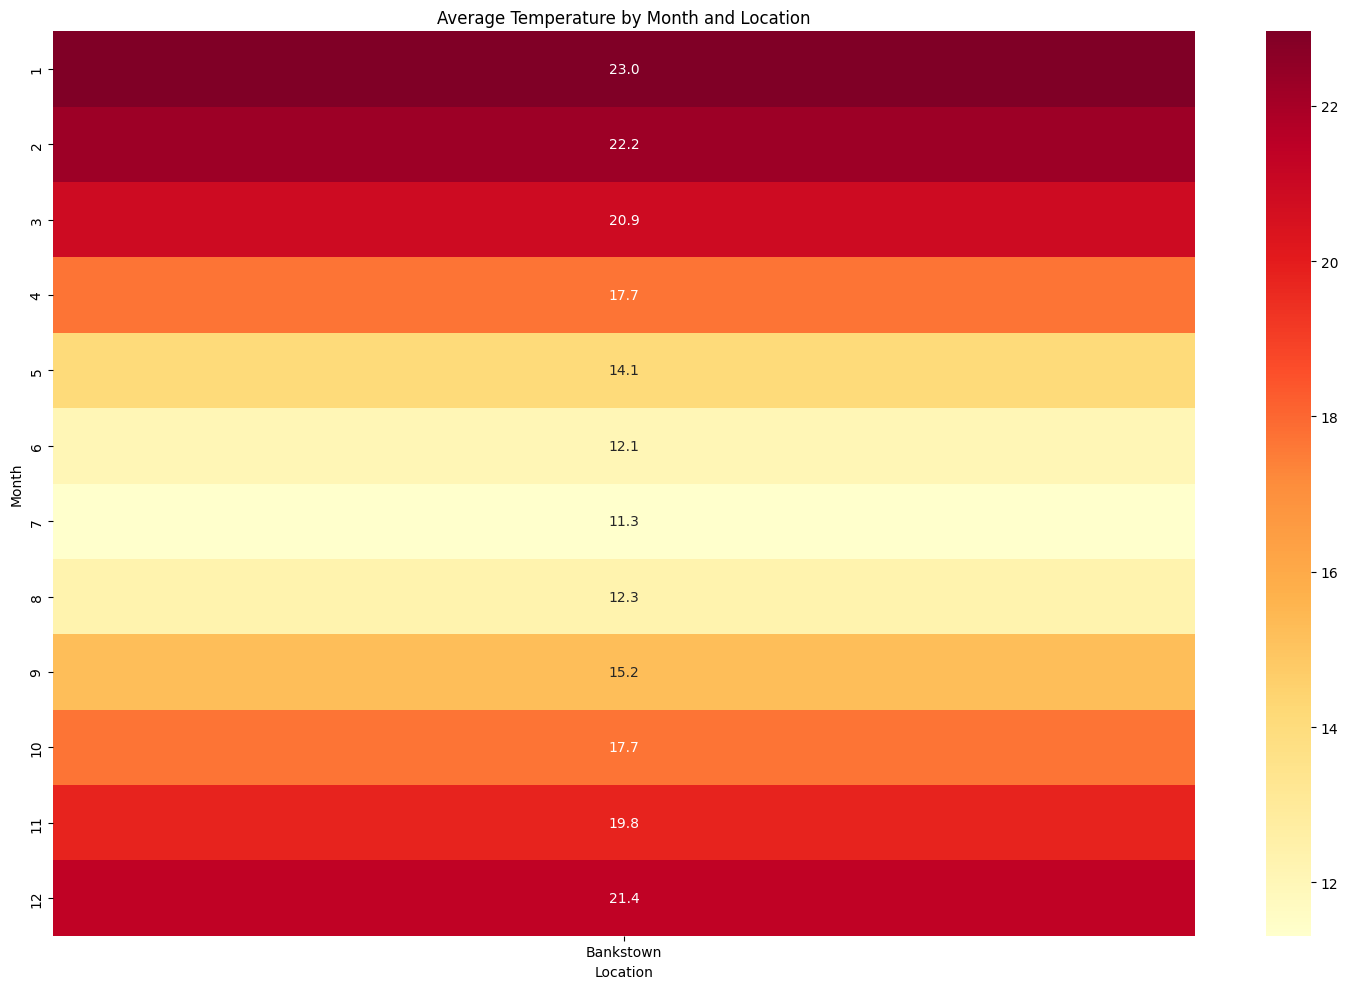


Monthly averages (sorted from highest to lowest):
January: 22.96°C
February: 22.24°C
December: 21.39°C
March: 20.90°C
November: 19.80°C
October: 17.72°C
April: 17.71°C
September: 15.24°C
May: 14.10°C
August: 12.35°C
June: 12.06°C
July: 11.31°C

Location averages (sorted from highest to lowest):
Bankstown: 17.42°C
Data range: from 2010-01-01 00:00:00 to 2021-03-18 00:00:00
Total number of days: 4094
Average temperature: 17.42°C
Maximum temperature: 44.70°C on 2020-01-04 13:00:00
Minimum temperature: -1.30°C on 2018-07-16 06:30:00


In [4]:
# Descriptive Analysis -
# Part 1 Temperature Data
# redoing ingestion as it requires  for every run
file_path = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_nsw\temperature_nsw.csv"
temp = pd.read_csv(file_path)

temp['DATETIME'] = pd.to_datetime(temp['DATETIME'], format='%d/%m/%Y %H:%M')
temp.set_index('DATETIME', inplace=True)
temp_daily = temp.groupby('LOCATION').resample('D')['TEMPERATURE'].mean().reset_index()

plt.figure(figsize=(15, 10))
for location in temp['LOCATION'].unique():
    location_data = temp_daily[temp_daily['LOCATION'] == location]
    plt.plot(location_data['DATETIME'], location_data['TEMPERATURE'], label=location)

plt.title('Daily Average Temperature in NSW by Location')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

temp['month'] = temp.index.month
plt.figure(figsize=(15, 7))
sns.boxplot(x='month', y='TEMPERATURE', data=temp)
plt.title('Monthly Distribution of Temperature in NSW')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))
sns.histplot(temp['TEMPERATURE'], kde=True)
plt.title('Distribution of Temperature in NSW')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



pivot_temp = temp.pivot_table(values='TEMPERATURE', index=temp.index.month, columns='LOCATION', aggfunc='mean')
plt.figure(figsize=(15, 10))
sns.heatmap(pivot_temp, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Average Temperature by Month and Location')
plt.xlabel('Location')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

monthly_avg = temp.groupby(temp.index.month)['TEMPERATURE'].mean().sort_values(ascending=False)
print("\nMonthly averages (sorted from highest to lowest):")
for month, avg in monthly_avg.items():
    print(f"{datetime(2000, month, 1).strftime('%B')}: {avg:.2f}°C")

location_avg = temp.groupby('LOCATION')['TEMPERATURE'].mean().sort_values(ascending=False)
print("\nLocation averages (sorted from highest to lowest):")
for location, avg in location_avg.items():
    print(f"{location}: {avg:.2f}°C")

print(f"Data range: from {temp.index.min()} to {temp.index.max()}")
print(f"Total number of days: {(temp.index.max() - temp.index.min()).days}")
print(f"Average temperature: {temp['TEMPERATURE'].mean():.2f}°C")
print(f"Maximum temperature: {temp['TEMPERATURE'].max():.2f}°C on {temp['TEMPERATURE'].idxmax()}")
print(f"Minimum temperature: {temp['TEMPERATURE'].min():.2f}°C on {temp['TEMPERATURE'].idxmin()}")

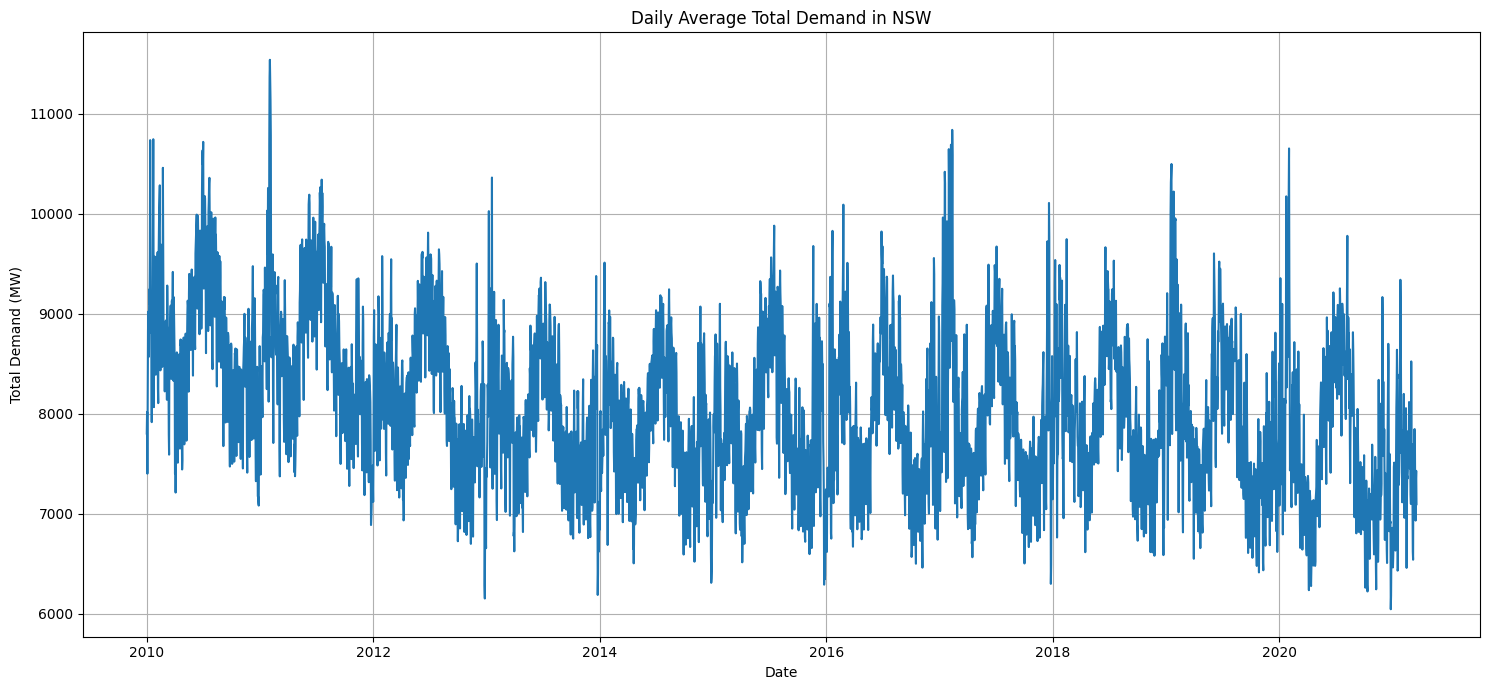

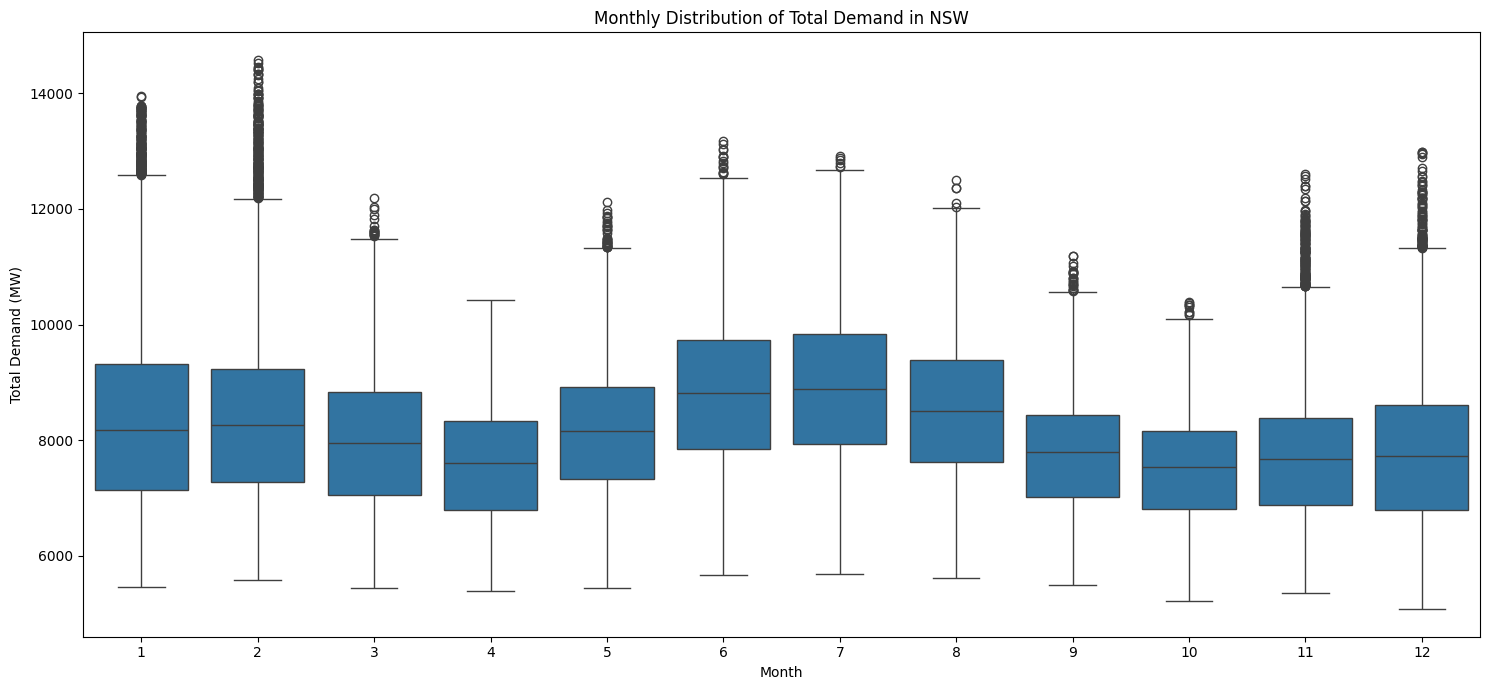

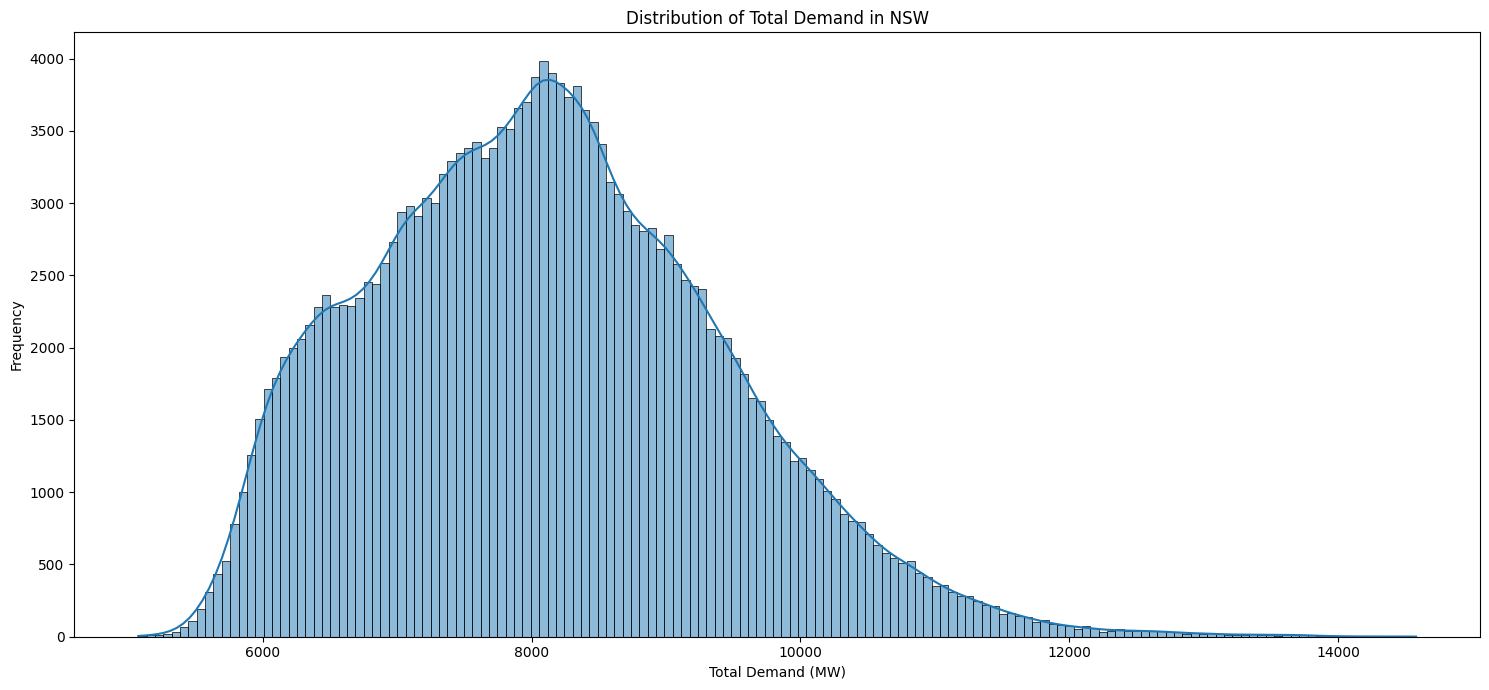

Data range: from 2010-01-01 00:00:00 to 2021-03-18 00:00:00
Total number of days: 4094
Average daily demand: 8112.90 MW
Maximum daily average demand: 11539.82 MW on 2011-02-02 00:00:00
Minimum daily average demand: 6043.80 MW on 2020-12-25 00:00:00

Monthly averages (sorted from highest to lowest):
July: 8894.76 MW
June: 8799.72 MW
August: 8524.08 MW
January: 8348.57 MW
February: 8329.03 MW
May: 8150.53 MW
March: 7967.74 MW
December: 7773.64 MW
September: 7759.18 MW
November: 7703.03 MW
April: 7586.95 MW
October: 7488.18 MW


In [5]:
# Descriptive Analysis -
# Part 2 Total Demand
# redoing ingestion as it requires  for every run

file_path = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_nsw\totaldemand_nsw.csv"
td = pd.read_csv(file_path)

td['DATETIME'] = pd.to_datetime(td['DATETIME'], format='%d/%m/%Y %H:%M')
td.set_index('DATETIME', inplace=True)
td['TOTALDEMAND'] = pd.to_numeric(td['TOTALDEMAND'], errors='coerce')
td = td.dropna()
td_daily = td['TOTALDEMAND'].resample('D').mean()
plt.figure(figsize=(15, 7))
plt.plot(td_daily.index, td_daily.values)
plt.title('Daily Average Total Demand in NSW')
plt.xlabel('Date')
plt.ylabel('Total Demand (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()
td['month'] = td.index.month
plt.figure(figsize=(15, 7))
sns.boxplot(x='month', y='TOTALDEMAND', data=td)
plt.title('Monthly Distribution of Total Demand in NSW')
plt.xlabel('Month')
plt.ylabel('Total Demand (MW)')
plt.tight_layout()
plt.show()
plt.figure(figsize=(15, 7))
sns.histplot(td['TOTALDEMAND'], kde=True)
plt.title('Distribution of Total Demand in NSW')
plt.xlabel('Total Demand (MW)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Data range: from {td.index.min()} to {td.index.max()}")
print(f"Total number of days: {(td.index.max() - td.index.min()).days}")
print(f"Average daily demand: {td_daily.mean():.2f} MW")
print(f"Maximum daily average demand: {td_daily.max():.2f} MW on {td_daily.idxmax()}")
print(f"Minimum daily average demand: {td_daily.min():.2f} MW on {td_daily.idxmin()}")

monthly_avg = td.groupby(td.index.month)['TOTALDEMAND'].mean().sort_values(ascending=False)
print("\nMonthly averages (sorted from highest to lowest):")
for month, avg in monthly_avg.items():
    print(f"{datetime(2000, month, 1).strftime('%B')}: {avg:.2f} MW")

original_count = len(pd.read_csv(file_path))
final_count = len(td)
if original_count != final_count:
    print(f"\nWarning: {original_count - final_count} rows were removed due to non-numeric values in TOTALDEMAND.")

                              fc
DATETIME                        
2010-01-01 00:00:00  7824.411831
2010-01-01 00:30:00  7680.510417
2010-01-01 01:00:00  7428.971370
2010-01-01 01:30:00  7084.802162
2010-01-01 02:00:00  6751.369600


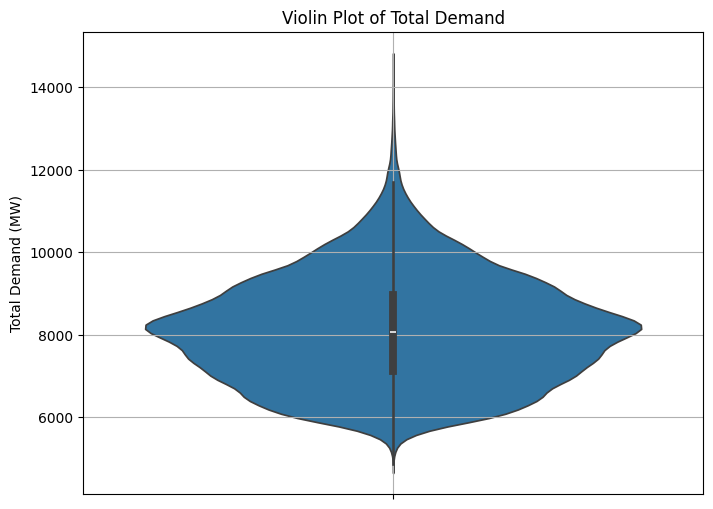

In [6]:
# Descriptive Analysis -
# Part 3 Forecasted Demand
# redoing ingestion as it requires  for every run

nsw = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_fcastd_nsw\forecastdemand_nsw_chunks" 
data_nsw = rebuild_function(nsw, "forecastdemand_nsw_part*.csv") 
# Aggregate by DATETIME and calculate median of FORECASTDEMAND 

if data_nsw is not None: 
    agg_nsw = data_nsw[['DATETIME','FORECASTDEMAND']] 
    agg_nsw = agg_nsw.groupby('DATETIME').mean() 
    agg_nsw.rename(columns={'FORECASTDEMAND':'fc'}, inplace=True) 
    print(agg_nsw.head()) 
else: 
    print("No data was aggregated due to previous errors.") 
agg_nsw.rename({'DATETIME': 'datetime'}, inplace=True, axis=1) 
agg_nsw.rename_axis('datetime', inplace=True) 

plt.figure(figsize=(8, 6)) 
sns.violinplot(y=agg_nsw['fc']) 
plt.ylabel('Total Demand (MW)') 
plt.title('Violin Plot of Total Demand') 
plt.grid(True) 
plt.show() 

## Diagnostic Analytics

In [7]:
# Diagnostic Analysis -
# Determining the Baseline Performance
# Current (Actual) vs Forecasted Demand: MAE
# dumping the file for easier reference

# Use the function
nsw = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_fcastd_nsw\forecastdemand_nsw_chunks"
data_nsw = rebuild_function(nsw, "forecastdemand_nsw_part*.csv")

if data_nsw is not None:
    # Convert DATETIME to datetime type if it's not already
    data_nsw['DATETIME'] = pd.to_datetime(data_nsw['DATETIME'])
    
    # Sort the data by DATETIME and PERIODID
    data_nsw_sorted = data_nsw.sort_values(by=['DATETIME', 'PERIODID'], ascending=[True, True])
    
    # Get the first (earliest) forecast for each DATETIME
    agg_nsw_first = data_nsw_sorted.groupby('DATETIME').first()[['FORECASTDEMAND']]
    agg_nsw_first.rename(columns={'FORECASTDEMAND': 'fc_first'}, inplace=True)
    
    # Rename the index to 'datetime' for consistency
    agg_nsw_first.index.name = 'datetime'
    
    print("Earliest Forecast:")
    print(agg_nsw_first.head())
    
    # Join with actual demand data (td)
    td.rename_axis('datetime', inplace=True)
    td.rename(columns={'TOTALDEMAND': 'actual'}, inplace=True)
    td = td[['actual']]
    
    # Convert index to datetime in both DataFrames if not already
    agg_nsw_first.index = pd.to_datetime(agg_nsw_first.index)
    td.index = pd.to_datetime(td.index)
    
    # Perform the join
    m_first = agg_nsw_first.join(td, on='datetime', how='inner')
    
    # Display the result
    print("\nEarliest Forecast with Actual Demand:")
    print(m_first.head())
    
    # Save to CSV
    m_first.to_csv('final-model-first.csv')
else:
    print("No data was aggregated due to previous errors.")

Earliest Forecast:
                     fc_first
datetime                     
2010-01-01 00:00:00   7999.11
2010-01-01 00:30:00   7596.21
2010-01-01 01:00:00   7380.70
2010-01-01 01:30:00   7022.05
2010-01-01 02:00:00   6682.92

Earliest Forecast with Actual Demand:
                     fc_first   actual
datetime                              
2010-01-01 00:00:00   7999.11  8038.00
2010-01-01 00:30:00   7596.21  7809.31
2010-01-01 01:00:00   7380.70  7483.69
2010-01-01 01:30:00   7022.05  7117.23
2010-01-01 02:00:00   6682.92  6812.03


C:\Users\maric\AppData\Local\Temp\ipykernel_22476\2483945179.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = m_first.resample('M').mean()
C:\Users\maric\AppData\Local\Temp\ipykernel_22476\2483945179.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_data = m_first.resample('Y').mean()


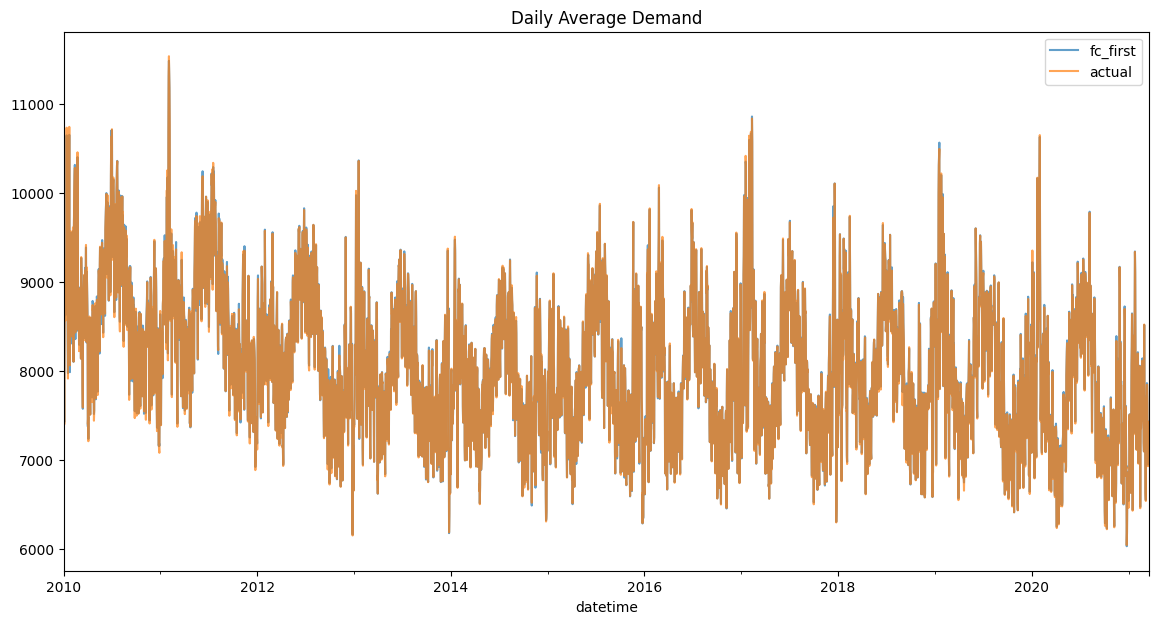

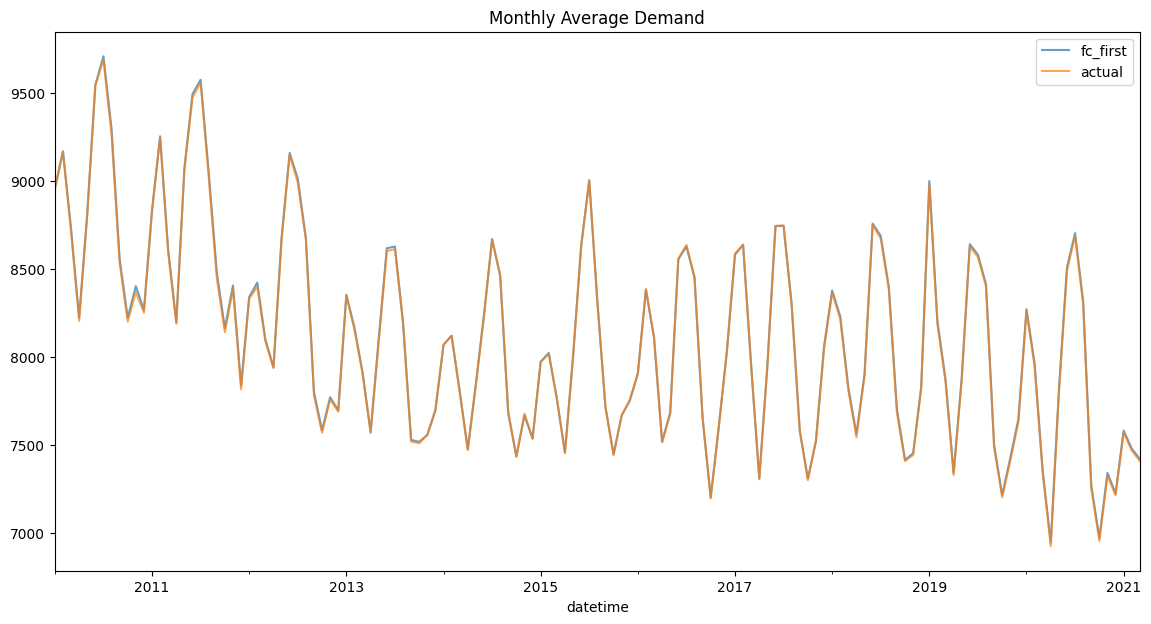

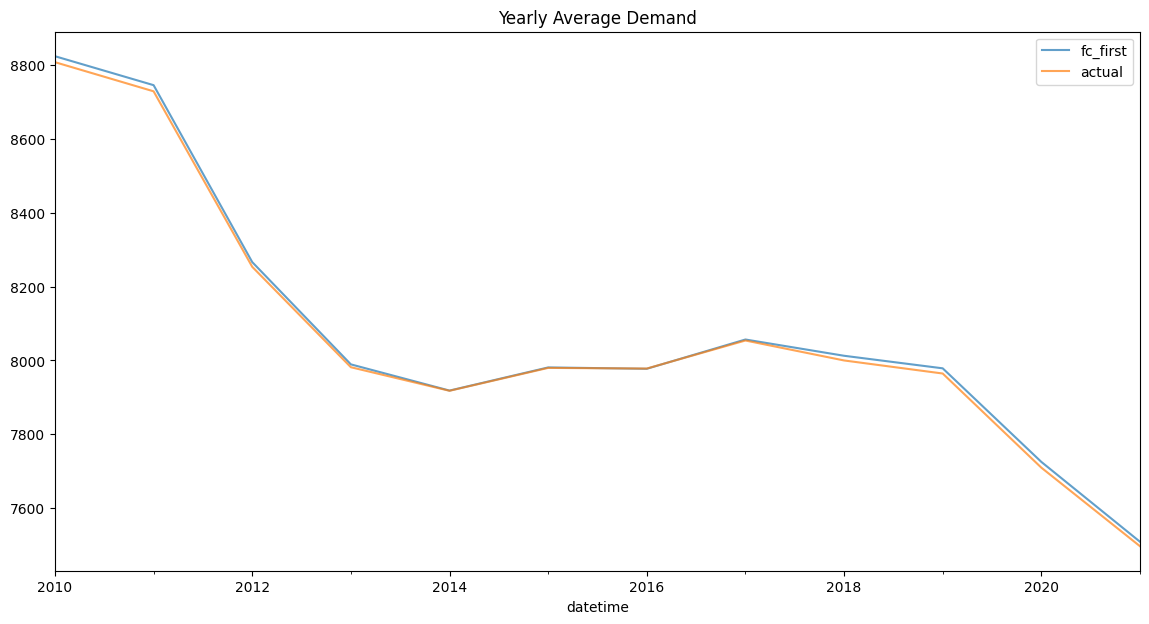

In [8]:
# Diagnostic Analysis -
# Determining the Baseline Performance - Visualization Time Series
# Current (Actual) vs Forecasted Demand: MAE
# dumping the file for easier reference

# Resampling data - to aggregate the data over a larger time period 
daily_data = m_first.resample('D').mean()
monthly_data = m_first.resample('M').mean()
yearly_data = m_first.resample('Y').mean()

# Plot the daily average
daily_data[['fc_first', 'actual']].plot(figsize=(14, 7), alpha=0.7)
plt.title('Daily Average Demand')
plt.show()

# Plot the monthly average
monthly_data[['fc_first', 'actual']].plot(figsize=(14, 7), alpha=0.7)
plt.title('Monthly Average Demand')
plt.show()

# Plot the yearly average
yearly_data[['fc_first', 'actual']].plot(figsize=(14, 7), alpha=0.7)
plt.title('Yearly Average Demand')
plt.show()

In [9]:
# Diagnostic Analysis -
# Determining the Baseline Performance - Measurement Across different aggregation techniques (First, Last and Average)
# TOTAL - MEASUREMENT : THIS IS TO DETERMINE THE INITIAL PERFORMANCE PURPOSES
# Current (Actual) vs Forecasted Demand


# Use the function
nsw = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_fcastd_nsw\forecastdemand_nsw_chunks"
data_nsw = rebuild_function(nsw, "forecastdemand_nsw_part*.csv")


data_nsw_simplified_1 = data_nsw[['PERIODID', 'DATETIME', 'FORECASTDEMAND']].copy()
data_nsw_simplified_1.rename(columns={
    'PERIODID': 'periodid',
    'DATETIME': 'datetime',
    'FORECASTDEMAND': 'fcast'
}, inplace=True)

fd_nsw = data_nsw_simplified_1.copy()
fd_nsw['datetime'] = pd.to_datetime(fd_nsw['datetime'])

# Sort the data by datetime and PERIODID (descending to have most recent forecast last)
data_nsw_sorted = fd_nsw.sort_values(by=['datetime', 'periodid'], ascending=[True, True])
most_recent_forecast = data_nsw_sorted.groupby('datetime').first().reset_index()
earliest_forecast = data_nsw_sorted.groupby('datetime').last().reset_index()
avg_forecast = data_nsw_sorted.groupby('datetime')['fcast'].mean().reset_index()
# Prepare the dataframe for analysis
analysis_df_mr = most_recent_forecast[['datetime', 'fcast', 'periodid']].copy()
analysis_df_mr.set_index('datetime', inplace=True)
analysis_df_ef = earliest_forecast[['datetime', 'fcast', 'periodid']].copy()
analysis_df_ef.set_index('datetime', inplace=True)


analysis_df_avg = avg_forecast[['datetime', 'fcast']].copy()
analysis_df_avg.set_index('datetime', inplace=True)

mr = analysis_df_mr.join(td, on='datetime',how='inner')
ef = analysis_df_ef.join(td, on='datetime',how='inner')
av = analysis_df_avg.join(td, on='datetime',how='inner')

# Calculate MAE, RMSE, and MAPE
mae = mean_absolute_error(mr['actual'], mr['fcast'])
rmse = np.sqrt(mean_squared_error(mr['actual'], mr['fcast']))
mape = np.mean(np.abs((mr['actual'] - mr['fcast']) / mr['actual'])) * 100

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Square Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

# Contextualizing the results
mean_demand = mr['actual'].mean()
max_demand = mr['actual'].max()
min_demand = mr['actual'].min()
range_demand = max_demand - min_demand

mae_relative = mae / mean_demand
rmse_relative = rmse / mean_demand

print(f"MAE as a percentage of mean demand (most recent): {mae_relative * 100:.2f}%")
print(f"RMSE as a percentage of mean demand (most recent): {rmse_relative * 100:.2f}%")

# Calculate MAE, RMSE, and MAPE
mae = mean_absolute_error(ef['actual'], ef['fcast'])
rmse = np.sqrt(mean_squared_error(ef['actual'], ef['fcast']))
mape = np.mean(np.abs((ef['actual'] - ef['fcast']) / ef['actual'])) * 100

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Square Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

# Contextualizing the results
mean_demand = ef['actual'].mean()
max_demand = ef['actual'].max()
min_demand = ef['actual'].min()
range_demand = max_demand - min_demand

mae_relative = mae / mean_demand
rmse_relative = rmse / mean_demand

print(f"MAE as a percentage of mean demand (earliest forecast): {mae_relative * 100:.2f}%")
print(f"RMSE as a percentage of mean demand (earliest forecast): {rmse_relative * 100:.2f}%")

# Calculate MAE, RMSE, and MAPE
mae = mean_absolute_error(av['actual'], av['fcast'])
rmse = np.sqrt(mean_squared_error(av['actual'], av['fcast']))
mape = np.mean(np.abs((av['actual'] - av['fcast']) / av['actual'])) * 100

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Square Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

# Contextualizing the results
mean_demand = av['actual'].mean()
max_demand = av['actual'].max()
min_demand = av['actual'].min()
range_demand = max_demand - min_demand

mae_relative = mae / mean_demand
rmse_relative = rmse / mean_demand

print(f"MAE as a percentage of mean demand (avg forecast): {mae_relative * 100:.2f}%")
print(f"RMSE as a percentage of mean demand (avg forecast): {rmse_relative * 100:.2f}%")

Mean Absolute Error (MAE): 62.33
Root Mean Square Error (RMSE): 85.87
Mean Absolute Percentage Error (MAPE): 0.76%
MAE as a percentage of mean demand (most recent): 0.77%
RMSE as a percentage of mean demand (most recent): 1.06%
Mean Absolute Error (MAE): 179.69
Root Mean Square Error (RMSE): 249.29
Mean Absolute Percentage Error (MAPE): 2.18%
MAE as a percentage of mean demand (earliest forecast): 2.21%
RMSE as a percentage of mean demand (earliest forecast): 3.07%
Mean Absolute Error (MAE): 150.63
Root Mean Square Error (RMSE): 208.59
Mean Absolute Percentage Error (MAPE): 1.83%
MAE as a percentage of mean demand (avg forecast): 1.86%
RMSE as a percentage of mean demand (avg forecast): 2.57%


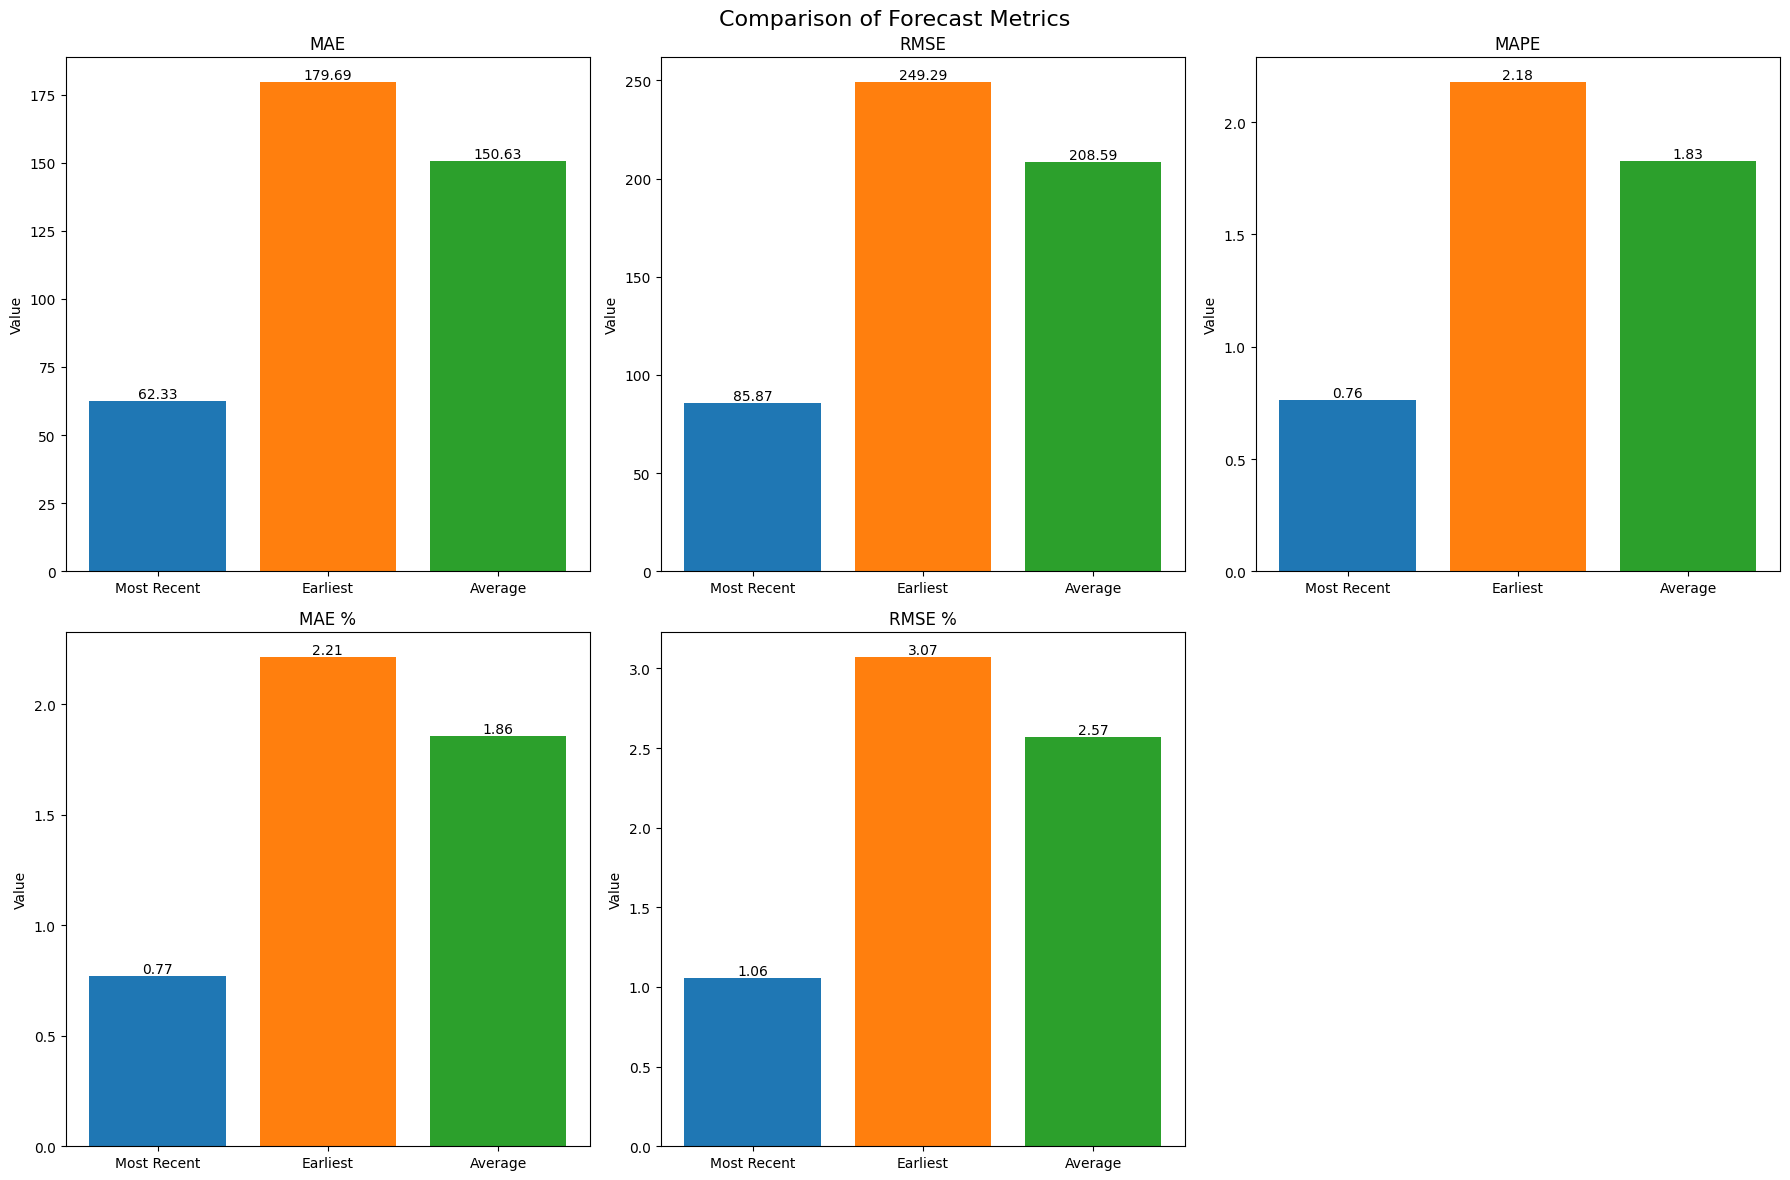


Most Recent Forecast:
MAE: 62.33
RMSE: 85.87
MAPE: 0.76
MAE %: 0.77
RMSE %: 1.06

Earliest Forecast:
MAE: 179.69
RMSE: 249.29
MAPE: 2.18
MAE %: 2.21
RMSE %: 3.07

Average Forecast:
MAE: 150.63
RMSE: 208.59
MAPE: 1.83
MAE %: 1.86
RMSE %: 2.57


In [10]:
# Diagnostic Analysis -
# Determining the Baseline Performance - Measurement Across different aggregation techniques (First, Last and Average)
# TOTAL - MEASUREMENT : THIS IS TO DETERMINE THE INITIAL PERFORMANCE PURPOSES
# Current (Actual) vs Forecasted Demand

# Function to calculate metrics
def calculate_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    mean_demand = actual.mean()
    mae_relative = mae / mean_demand * 100
    rmse_relative = rmse / mean_demand * 100
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'MAE %': mae_relative,
        'RMSE %': rmse_relative
    }

# Calculate metrics for each forecast type
metrics = {
    'Most Recent': calculate_metrics(mr['actual'], mr['fcast']),
    'Earliest': calculate_metrics(ef['actual'], ef['fcast']),
    'Average': calculate_metrics(av['actual'], av['fcast'])
}

# Set up the plot
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comparison of Forecast Metrics', fontsize=16)

# List of metrics to plot
metric_list = ['MAE', 'RMSE', 'MAPE', 'MAE %', 'RMSE %']

# Colors for each forecast type
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Plot each metric
for i, metric in enumerate(metric_list):
    row = i // 3
    col = i % 3
    
    values = [metrics[f_type][metric] for f_type in ['Most Recent', 'Earliest', 'Average']]
    
    axs[row, col].bar(['Most Recent', 'Earliest', 'Average'], values, color=colors)
    axs[row, col].set_title(metric)
    axs[row, col].set_ylabel('Value')
    
    # Add value labels on top of each bar
    for j, v in enumerate(values):
        axs[row, col].text(j, v, f'{v:.2f}', ha='center', va='bottom')

    # Set y-axis to start from 0
    axs[row, col].set_ylim(bottom=0)

# Remove the empty subplot
fig.delaxes(axs[1, 2])

plt.tight_layout()
plt.show()

# Print the metrics for verification
for forecast_type, metric_values in metrics.items():
    print(f"\n{forecast_type} Forecast:")
    for metric, value in metric_values.items():
        print(f"{metric}: {value:.2f}")

In [11]:
# Diagnostic Analysis -
# Determining the Baseline Performance - NEXT 30 MIN (MOST RECENT)
# TEST - MEASUREMENT : THIS IS TO DETERMINE MAE FOR UNSEEN DATA
# Current (Actual) vs Forecasted Demand

# Split the data into training and testing sets (80% train, 20% test)
train_size = 0.8

actual=mr['actual'].copy()
forecast=mr['fcast'].copy()

# Assuming `actual` and `forecast` are pandas Series
actual_train, actual_test = train_test_split(actual, train_size=train_size, shuffle=False)
forecast_train, forecast_test = train_test_split(forecast, train_size=train_size, shuffle=False)

# Function to calculate metrics (same as yours)
def calculate_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    mean_demand = actual.mean()
    mae_relative = mae / mean_demand * 100
    rmse_relative = rmse / mean_demand * 100
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'MAE %': mae_relative,
        'RMSE %': rmse_relative
    }

# Calculate metrics for the test period
test_metrics = calculate_metrics(actual_test, forecast_test)

# Print the MAE for the test period
print(f"\nTest MAE (MOST RECENT): {test_metrics['MAE']:.2f}")


Test MAE (MOST RECENT): 50.91


In [12]:
# Diagnostic Analysis -
# Determining the Lag Correlations between Temperature and Forecast
# Data Preprocessing


# Split the data into training and testing sets (80% train, 20% test)
file_path = r"C:\Users\maric\Documents\GitProjects\project\report\notebooks\travis_dev\unzip_nsw\temperature_nsw.csv"
temp = pd.read_csv(file_path)
d = pd.read_csv('final-model-first.csv')

temp['DATETIME'] = pd.to_datetime(temp['DATETIME'], dayfirst=True)
temp.set_index('DATETIME', inplace=True)
if 'month' in temp.columns:
    temp.drop(columns=['LOCATION', 'month'], inplace=True)
else:
    temp.drop(columns=['LOCATION'], inplace=True)
temp.rename(columns={'TEMPERATURE': 'temp'}, inplace=True)

# attempting to generalized the temperature
temp_ts = temp['temp'].copy()
weights = {
    'Bankstown': 0.05,   # City Temperature
    'Inland': 0.70,      # Inland should have the largest weight
    'Mountain': 0.15,    # Mountain areas, 15% (example)
    'Coastal': 0.10      # Coastal should have lower weight
}

def calculate_weighted_temperature(row):
    weighted_temp = 0
    for region in ['Bankstown', 'Inland', 'Mountain', 'Coastal']:
        weighted_temp += row[region] * weights[region]
    return weighted_temp

def random_adjustment(base, lower_bound, upper_bound):
    return base + np.random.uniform(lower_bound, upper_bound, len(temp_ts))

# Apply random adjustments based on characteristics of inland, mountainous, and coastal regions
df_temp_ts_inland = random_adjustment(temp_ts, 2.0, 4.0)  # Random bias between +2°C and +4°C
df_temp_ts_mountain = random_adjustment(temp_ts, -6.0, -4.0)  # Random bias between -6°C and -4°C
df_temp_ts_coastal = random_adjustment(temp_ts, -3.0, -1.0)  # Random bias between -3°C and -1°C

# Combine into a new DataFrame for comparison
df_generalized = pd.DataFrame({
    'Bankstown': temp_ts,
    'Inland': df_temp_ts_inland,
    'Mountain': df_temp_ts_mountain,
    'Coastal': df_temp_ts_coastal
})

def calculate_weighted_temperature(row):
    weighted_temp = 0
    for region in ['Bankstown', 'Inland', 'Mountain', 'Coastal']:
        weighted_temp += row[region] * weights[region]
    return weighted_temp

df_generalized['generalized_temperature'] = df_generalized[['Bankstown', 'Inland', 'Mountain', 'Coastal']].apply(calculate_weighted_temperature, axis=1)



d['datetime'] = pd.to_datetime(d['datetime'], errors='coerce')
d.set_index('datetime', inplace=True)
df_generalized.rename(columns={'Bankstown': 'temp'}, inplace=True)
merged_data = d.join(df_generalized[['temp']], how='inner')
e_data = merged_data[['fc_first','temp']]
e_data.to_csv('for_prediction_fc_temp.csv')
#e_data.head()



The highest correlation of -0.4222 occurs at a lag of 212 windows.


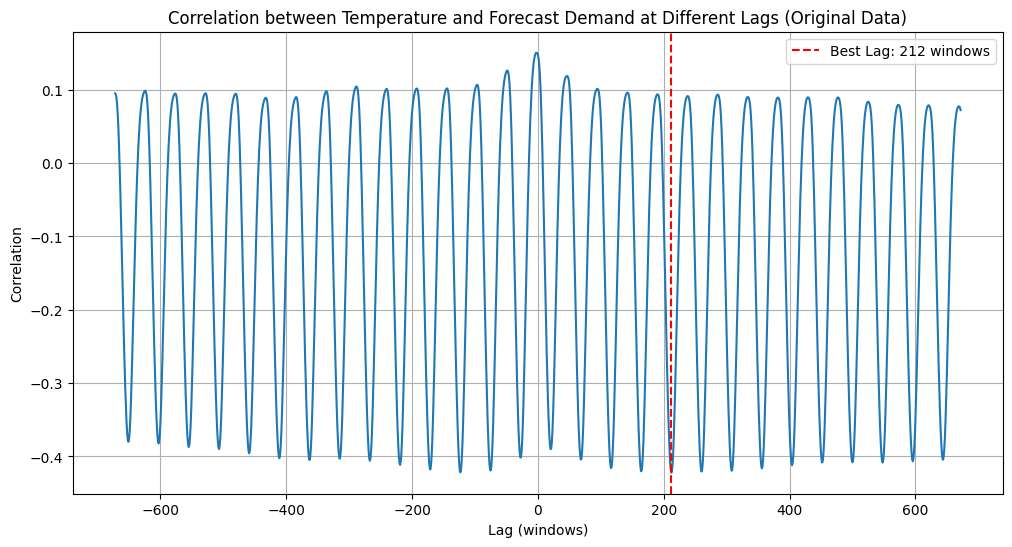

In [13]:
# Diagnostic Analysis -
# Determining the Lag Correlations between Temperature and Forecast - Visualisation
# Data Preprocessing

def calculate_lag_correlations(data, max_lag_windows):
    # Calculate lag correlations for the raw data
    lag_correlations = [
        data['temp'].corr(data['fc_first'].shift(lag))
        for lag in range(-max_lag_windows, max_lag_windows + 1)
    ]
    return lag_correlations

# 2. Set the max lag in windows (each window represents a 30-minute interval)
max_lag_windows = 672  # You can adjust this as needed

# 3. Run the lag correlation analysis on the original data (without resampling)
lag_correlations = calculate_lag_correlations(e_data, max_lag_windows)

# 4. Find the best lag (highest absolute correlation)
best_lag_windows = np.argmax(np.abs(lag_correlations)) - max_lag_windows
best_correlation = lag_correlations[best_lag_windows + max_lag_windows]

print(f"The highest correlation of {best_correlation:.4f} occurs at a lag of {best_lag_windows} windows.")

# 5. Plot the lag correlations
plt.figure(figsize=(12, 6))
plt.plot(range(-max_lag_windows, max_lag_windows + 1), lag_correlations)
plt.title('Correlation between Temperature and Forecast Demand at Different Lags (Original Data)')
plt.xlabel('Lag (windows)')
plt.ylabel('Correlation')
plt.axvline(x=best_lag_windows, color='r', linestyle='--', label=f'Best Lag: {best_lag_windows} windows')
plt.legend()
plt.grid(True)
plt.show()


## Predictive and Model Performance

In [14]:
e_data = pd.read_csv('for_prediction_fc_temp.csv')
e_data = e_data.rename(columns={'Unnamed: 0': 'datetime', 'fc_first':'fcast','temp': 'generalized_temperature'})
e_data['datetime'] = pd.to_datetime(e_data['datetime'])
x_data = e_data.copy()
x_data['hour'] = x_data['datetime'].dt.hour
x_data['day_of_week'] = x_data['datetime'].dt.dayofweek

# Step 1: Creating Lag Features
x_data['Lag1'] = x_data['fcast'].shift(1)
x_data['Lag2'] = x_data['fcast'].shift(2)
x_data['Lag39'] = x_data['fcast'].shift(39)
x_data['Lag41'] = x_data['fcast'].shift(41)
x_data['Lag47'] = x_data['fcast'].shift(47)
x_data['Lag48'] = x_data['fcast'].shift(48)
x_data['Lag49'] = x_data['fcast'].shift(49)
x_data['Lag50'] = x_data['fcast'].shift(50)

# Step 2: Creating Cyclical Temporal Features
x_data['hour_sin'] = np.sin(2 * np.pi * x_data['hour'] / 24)
x_data['hour_cos'] = np.cos(2 * np.pi * x_data['hour'] / 24)

x_data['dayofweek_sin'] = np.sin(2 * np.pi * x_data['day_of_week'] / 7)
x_data['dayofweek_cos'] = np.cos(2 * np.pi * x_data['day_of_week'] / 7)

# Extract 'month' and 'day_of_year' from 'datetime' column
x_data['datetime'] = pd.to_datetime(x_data['datetime'])
x_data['month'] = x_data['datetime'].dt.month
x_data['day_of_year'] = x_data['datetime'].dt.dayofyear

# Cyclical encoding for 'month' and 'day_of_year'
x_data['month_sin'] = np.sin(2 * np.pi * x_data['month'] / 12)
x_data['month_cos'] = np.cos(2 * np.pi * x_data['month'] / 12)

x_data['dayofyear_sin'] = np.sin(2 * np.pi * x_data['day_of_year'] / 365)
x_data['dayofyear_cos'] = np.cos(2 * np.pi * x_data['day_of_year'] / 365)

# Step 3: Creating 'TempSquared' Feature
x_data['TempSquared'] = x_data['generalized_temperature'] ** 2

# Step 4: Handling Missing Values from Lag Creation
x_data.dropna(inplace=True)

# The dataset is now aligned with the features used by your colleague
a =x_data[['datetime',
        'generalized_temperature',
        'fcast',
        'Lag1',
        'Lag2',
        'Lag39',
        'Lag41',
        'Lag47',
        'Lag48',
        'Lag49',
        'Lag50',
        'hour_sin',
        'hour_cos', 
        'dayofweek_sin', 
        'dayofweek_cos', 
        'month_sin', 
        'month_cos',
       'dayofyear_sin', 
       'dayofyear_cos', 
       'TempSquared'
        ]].copy()
x_data.to_csv('model_data_jwang.csv')



In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

# Load the data
b_data = pd.read_csv('final-model-first.csv')  # Baseline data
g_data = pd.read_csv('model_data_jwang.csv')   # Data for models

# Ensure datetime is in the correct format and sorted
b_data['datetime'] = pd.to_datetime(b_data['datetime'])
g_data['datetime'] = pd.to_datetime(g_data['datetime'])
b_data = b_data.sort_values(by='datetime')
g_data = g_data.sort_values(by='datetime')

# Align the datasets
common_dates = set(b_data['datetime']) & set(g_data['datetime'])
b_data = b_data[b_data['datetime'].isin(common_dates)].reset_index(drop=True)
g_data = g_data[g_data['datetime'].isin(common_dates)].reset_index(drop=True)

# Extract features for XGBoost and Random Forest
X = g_data[['generalized_temperature', 'Lag1', 'Lag2', 'Lag39','Lag41', 'Lag47', 'Lag48', 'Lag49', 'Lag50', 
       'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos',
       'dayofyear_sin', 'dayofyear_cos', 'TempSquared']]
y = g_data['fcast']

# Split the data for all models (shuffle=False to respect time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Split baseline data
train_size = len(X_train)
b_train, b_test = b_data.iloc[:train_size], b_data.iloc[train_size:]

# ... (rest of the code remains the same)
# Train the XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=900, subsample=0.9,
                             min_child_weight=3, max_depth=7, learning_rate=0.12, gamma=0,
                             colsample_bytree=1.0, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Baseline predictions (now using only the test portion)
y_pred_baseline = b_test['fc_first']
y_actual_baseline = b_test['actual']

# Function to calculate MAE and RMSE for a given window size
def compute_metrics_for_window(y_true, y_pred, window_size):
    y_true_window = y_true[:window_size]
    y_pred_window = y_pred[:window_size]
    mae = mean_absolute_error(y_true_window, y_pred_window)
    rmse = np.sqrt(mean_squared_error(y_true_window, y_pred_window))
    return mae, rmse

# Define window sizes
windows = {
    "a. Next 1 steps (next 30 mins)": 1,
    "b. Next 6 steps (next 3 hours)": 6,
    "c. Next 48 steps (next day)": 48,
    "d. Next 72 steps (next day + 12 hrs)": 72
}

# Consolidate results
models = {
    "Baseline": (y_actual_baseline, y_pred_baseline),
    "XGBoost": (y_test, y_pred_xgb),
    "Random Forest": (y_test, y_pred_rf)
}

# Report generation
report = []

for model_name, (y_true, y_pred) in models.items():
    print(f"\nModel: {model_name}")
    
    # Calculate total MAE and RMSE
    total_mae = mean_absolute_error(y_true, y_pred)
    total_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"Total MAE: {total_mae:.4f}")
    print(f"Total RMSE: {total_rmse:.4f}")
    
    # Add total metrics to report
    report.append({
        "Model": model_name,
        "Window": "Total",
        "MAE": total_mae,
        "RMSE": total_rmse
    })
    
    # Calculate MAE and RMSE for each window
    for window_name, window_size in windows.items():
        if window_size <= len(y_true):
            mae, rmse = compute_metrics_for_window(y_true, y_pred, window_size)
            print(f"{window_name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")
            
            # Add window-specific metrics to report
            report.append({
                "Model": model_name,
                "Window": window_name,
                "MAE": mae,
                "RMSE": rmse
            })
        else:
            print(f"{window_name} exceeds test set length for {model_name}")

# Convert report to a DataFrame for easier viewing
report_df = pd.DataFrame(report)
print("\nConsolidated Report:")
print(report_df)


Model: Baseline
Total MAE: 50.9132
Total RMSE: 68.8064
a. Next 1 steps (next 30 mins) -> MAE: 40.4200, RMSE: 40.4200
b. Next 6 steps (next 3 hours) -> MAE: 20.3517, RMSE: 25.4209
c. Next 48 steps (next day) -> MAE: 31.0131, RMSE: 38.1563
d. Next 72 steps (next day + 12 hrs) -> MAE: 36.3304, RMSE: 45.9806

Model: XGBoost
Total MAE: 66.8968
Total RMSE: 95.5257
a. Next 1 steps (next 30 mins) -> MAE: 49.1601, RMSE: 49.1601
b. Next 6 steps (next 3 hours) -> MAE: 32.7938, RMSE: 40.5709
c. Next 48 steps (next day) -> MAE: 42.5203, RMSE: 54.3824
d. Next 72 steps (next day + 12 hrs) -> MAE: 42.4388, RMSE: 53.7215

Model: Random Forest
Total MAE: 71.5458
Total RMSE: 100.1240
a. Next 1 steps (next 30 mins) -> MAE: 36.4952, RMSE: 36.4952
b. Next 6 steps (next 3 hours) -> MAE: 45.9821, RMSE: 54.4232
c. Next 48 steps (next day) -> MAE: 42.5949, RMSE: 51.6357
d. Next 72 steps (next day + 12 hrs) -> MAE: 43.7623, RMSE: 52.5768

Consolidated Report:
            Model                                Win

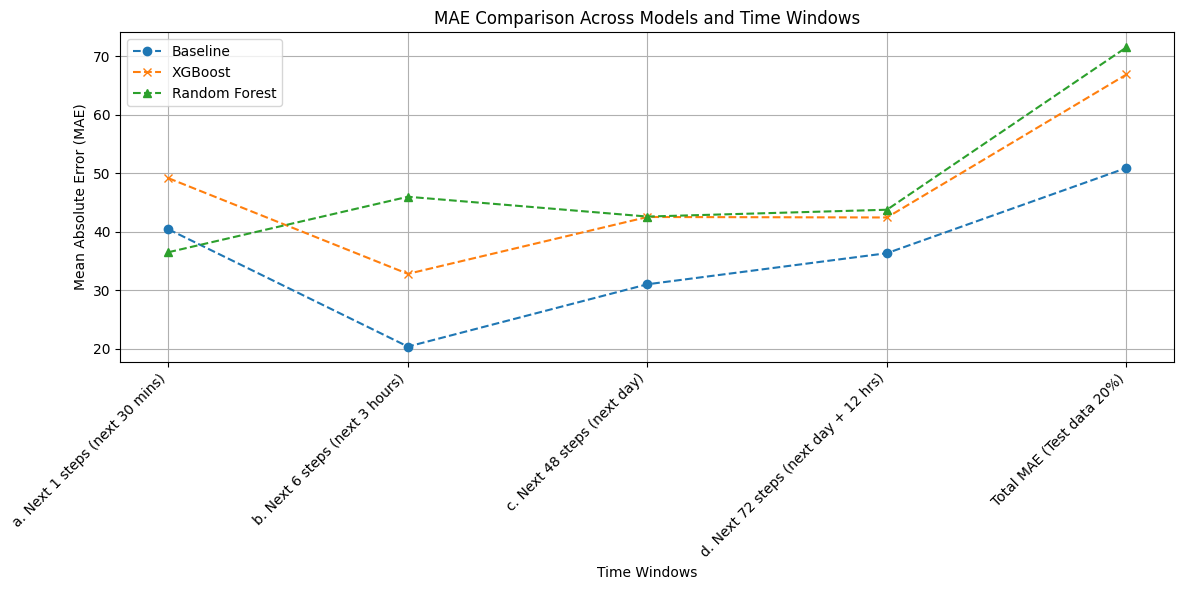

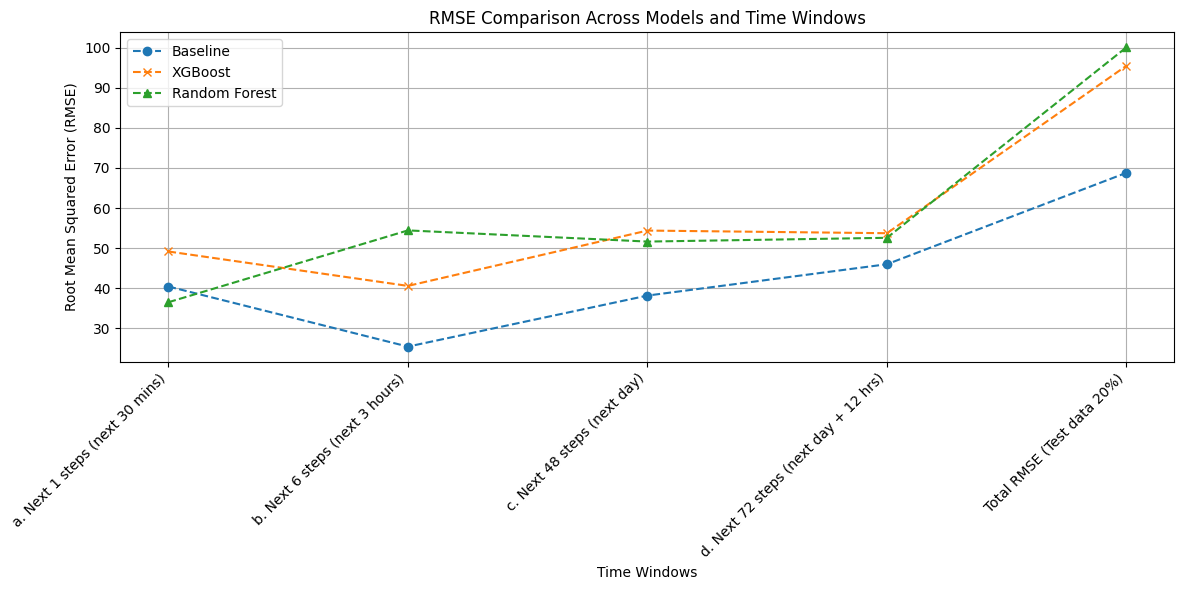

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming report_df is already created
report_df = pd.DataFrame(report)

# Create a pivot table to have models as columns and windows as rows for easy plotting
pivot_mae = report_df.pivot(index='Window', columns='Model', values='MAE')
pivot_rmse = report_df.pivot(index='Window', columns='Model', values='RMSE')

# Reorder the index to put 'Total' at the end and rename it
new_index = [idx for idx in pivot_mae.index if idx != 'Total'] + ['Total']
pivot_mae = pivot_mae.reindex(new_index)
pivot_rmse = pivot_rmse.reindex(new_index)
pivot_mae = pivot_mae.rename(index={'Total': 'Total MAE (Test data 20%)'})
pivot_rmse = pivot_rmse.rename(index={'Total': 'Total RMSE (Test data 20%)'})

# Plot MAE for different models across windows
plt.figure(figsize=(12, 6))
plt.plot(pivot_mae.index, pivot_mae['Baseline'], marker='o', label='Baseline', linestyle='--')
plt.plot(pivot_mae.index, pivot_mae['XGBoost'], marker='x', label='XGBoost', linestyle='--')
plt.plot(pivot_mae.index, pivot_mae['Random Forest'], marker='^', label='Random Forest', linestyle='--')
plt.title('MAE Comparison Across Models and Time Windows')
plt.xlabel('Time Windows')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show MAE plot
plt.show()

# Plot RMSE for different models across windows
plt.figure(figsize=(12, 6))
plt.plot(pivot_rmse.index, pivot_rmse['Baseline'], marker='o', label='Baseline', linestyle='--')
plt.plot(pivot_rmse.index, pivot_rmse['XGBoost'], marker='x', label='XGBoost', linestyle='--')
plt.plot(pivot_rmse.index, pivot_rmse['Random Forest'], marker='^', label='Random Forest', linestyle='--')
plt.title('RMSE Comparison Across Models and Time Windows')
plt.xlabel('Time Windows')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show RMSE plot
plt.show()